# Project Machine Learning
## Segmentasi Profil Pasien Berdasarkan Pola Gejala Klinis dan Data Demografis
**Metode:** Clustering (Unsupervised Learning)  
**Algoritma:** K-Means++, Gaussian Mixture Model (GMM), Agglomerative Clustering

In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARY & DATA UNDERSTANDING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score
from sklearn.decomposition import PCA
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore')

# 1. Memuat Dataset
df = pd.read_csv('synthetic_medical_triage.csv')

# 2. Preview data
print('5 Baris Pertama Dataset:')
display(df.head())

# 3. Dimensi data
print(f'\nJumlah baris dan kolom: {df.shape}')

# 4. Informasi tipe data dan missing values
print('\nInformasi Dataset:')
df.info()

# 5. Statistik deskriptif
print('\nStatistik Deskriptif:')
display(df.describe().round(2))

# 6. Distribusi triage_level (label referensi)
print('\nDistribusi Triage Level (label referensi, tidak dipakai saat training):')
print(df['triage_level'].value_counts().sort_index())

# 7. Distribusi arrival_mode
print('\nDistribusi Arrival Mode:')
print(df['arrival_mode'].value_counts())

5 Baris Pertama Dataset:


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0



Jumlah baris dan kolom: (18000, 10)

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  str    
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 1.4 MB

Statistik Deskriptif:


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,triage_level
count,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.0
mean,44.72,83.29,128.07,96.09,37.22,3.40,1.07,1.27,0.7
std,19.10,16.96,18.81,3.33,0.91,2.04,1.31,1.45,0.9
min,0.00,33.40,65.80,79.50,34.47,1.00,0.00,0.00,0.0
25%,31.20,71.50,114.90,94.30,36.58,2.00,0.00,0.00,0.0
50%,44.00,81.60,126.90,96.60,37.12,3.00,1.00,1.00,0.0
75%,57.50,93.20,139.90,98.70,37.77,5.00,2.00,2.00,1.0
max,95.00,152.30,219.70,100.00,41.13,10.00,10.00,11.00,3.0



Distribusi Triage Level (label referensi, tidak dipakai saat training):
triage_level
0    9924
1    4484
2    2701
3     891
Name: count, dtype: int64

Distribusi Arrival Mode:
arrival_mode
walk_in       11963
wheelchair     3067
ambulance      2970
Name: count, dtype: int64


In [2]:
# CELL 2: DATA PREPROCESSING

# 1. Memisahkan fitur dan target
y_true = df['triage_level']
X_raw = df.drop(columns=['triage_level', 'arrival_mode'])

print("Fitur yang digunakan untuk clustering:")
print(X_raw.columns.tolist())
print(f"\nJumlah fitur : {X_raw.shape[1]}")
print(f"Jumlah data  : {X_raw.shape[0]}")

# 2. Pengecekan Missing Values
print("\n=== Pengecekan Missing Values ===")
print(df.isnull().sum())
print("\nTidak ditemukan missing values, tidak diperlukan imputasi.")

# 3. Encoding Data Kategorikal
print("\n=== Encoding Data Kategorikal ===")
df_encoded = pd.get_dummies(df, columns=['arrival_mode'])
print("Kolom setelah encoding arrival_mode:")
print([col for col in df_encoded.columns if 'arrival_mode' in col])
print("\nKolom arrival_mode tidak diikutsertakan dalam clustering")
print("karena bersifat non-klinis dan tidak mencerminkan kondisi medis pasien.")

# 4. Deteksi Outlier dengan Metode IQR
print("\n=== Deteksi Outlier dengan Metode IQR ===\n")
for col in X_raw.columns:
    Q1 = X_raw[col].quantile(0.25)
    Q3 = X_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((X_raw[col] < lower) | (X_raw[col] > upper)).sum()
    print(f"{col}: {n_out} outlier ({n_out/len(X_raw)*100:.2f}%)")

print("\nOutlier tidak dihapus karena nilai ekstrem pada data medis")
print("merupakan sinyal klinis penting, bukan error data.")

# 5. Catatan Scaling
print("\n=== Catatan Scaling ===")
print("StandardScaler akan diterapkan di dalam loop setiap skenario splitting.")
print("Scaler hanya di-fit pada data training untuk menghindari data leakage.")

Fitur yang digunakan untuk clustering:
['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature', 'pain_level', 'chronic_disease_count', 'previous_er_visits']

Jumlah fitur : 8
Jumlah data  : 18000

=== Pengecekan Missing Values ===
age                        0
heart_rate                 0
systolic_blood_pressure    0
oxygen_saturation          0
body_temperature           0
pain_level                 0
chronic_disease_count      0
previous_er_visits         0
arrival_mode               0
triage_level               0
dtype: int64

Tidak ditemukan missing values, tidak diperlukan imputasi.

=== Encoding Data Kategorikal ===
Kolom setelah encoding arrival_mode:
['arrival_mode_ambulance', 'arrival_mode_walk_in', 'arrival_mode_wheelchair']

Kolom arrival_mode tidak diikutsertakan dalam clustering
karena bersifat non-klinis dan tidak mencerminkan kondisi medis pasien.

=== Deteksi Outlier dengan Metode IQR ===

age: 0 outlier (0.00%)
heart_rate: 317 outlier (1

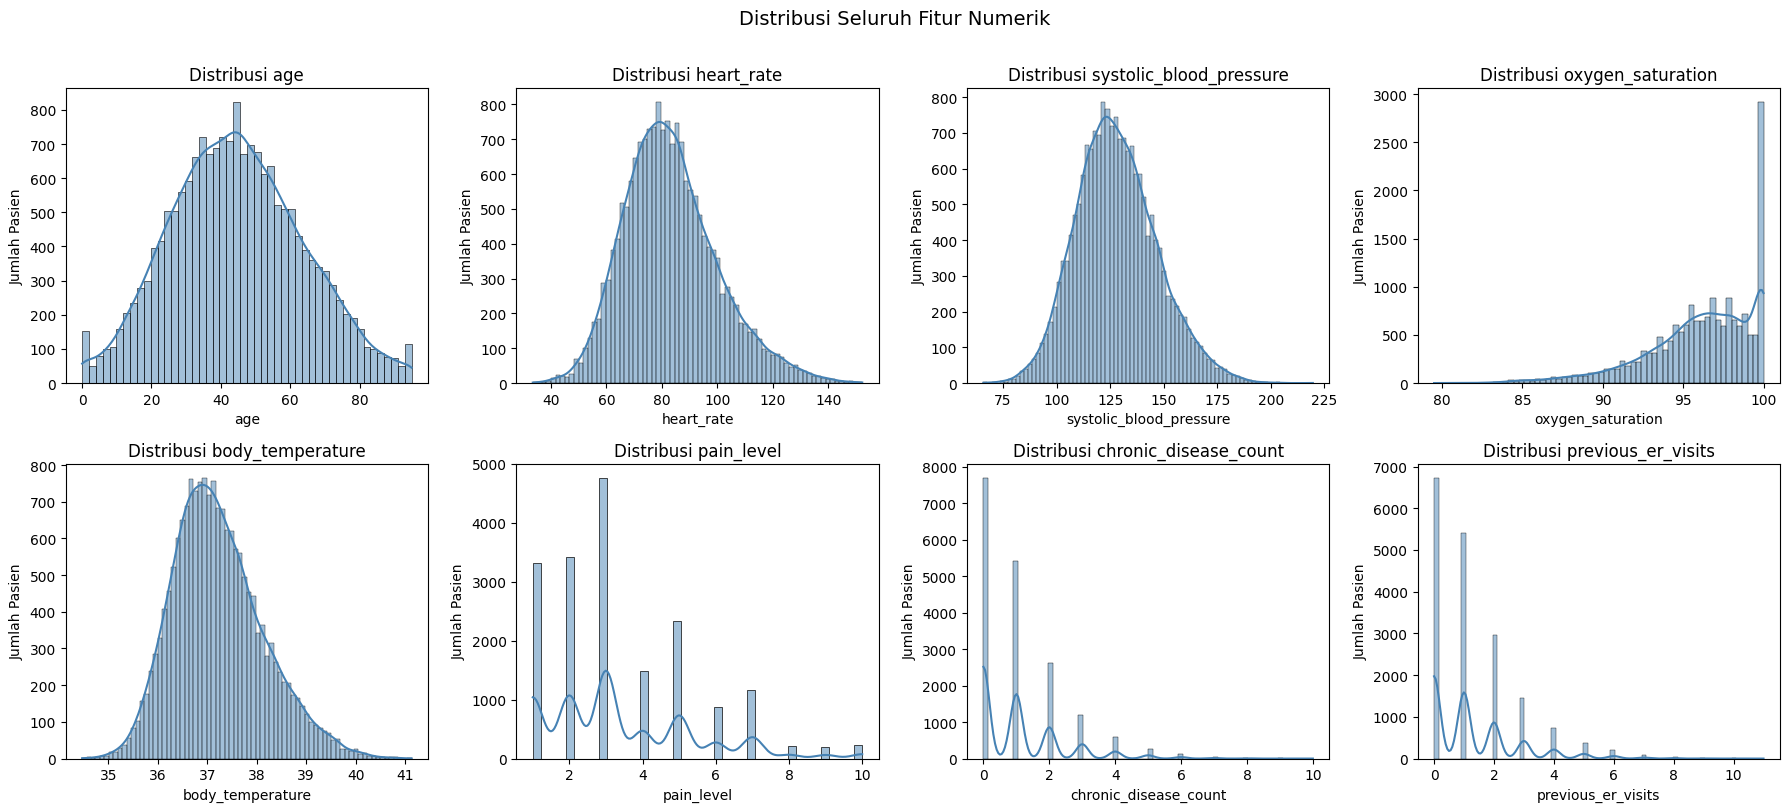

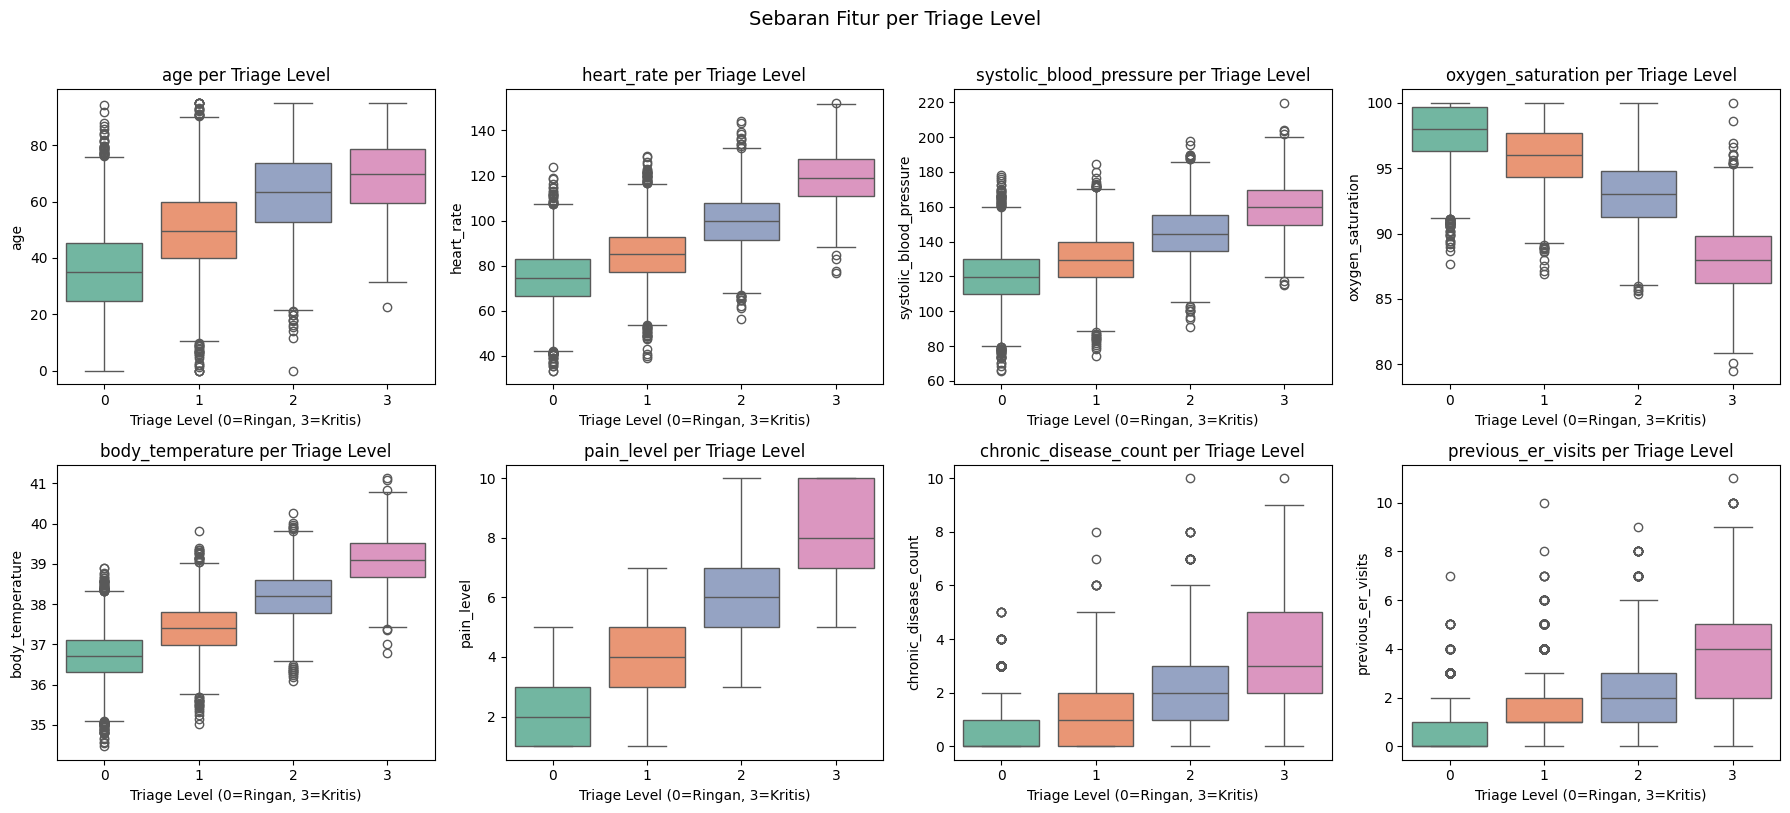

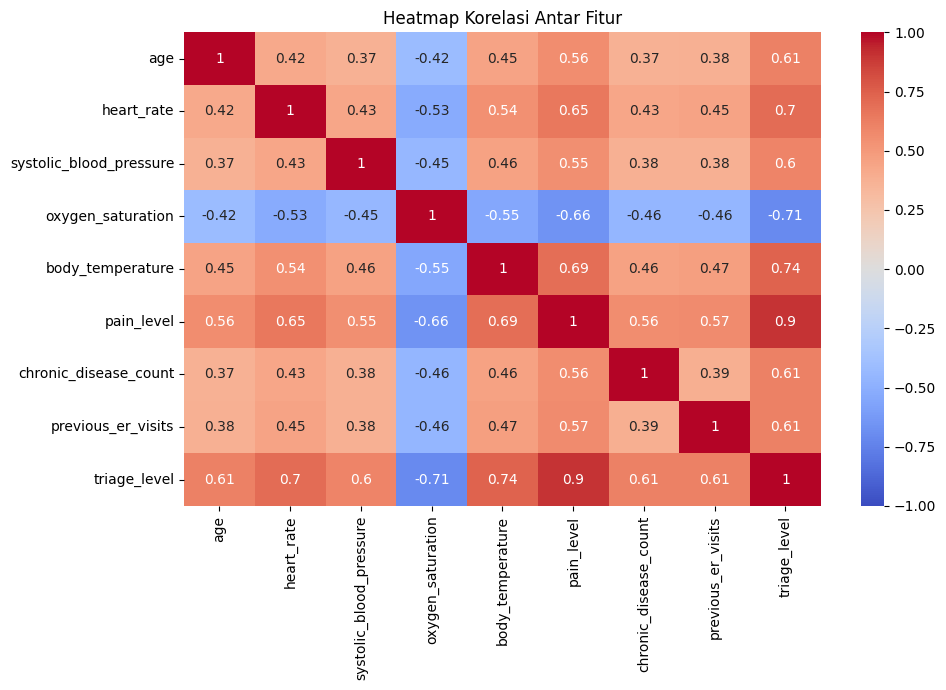

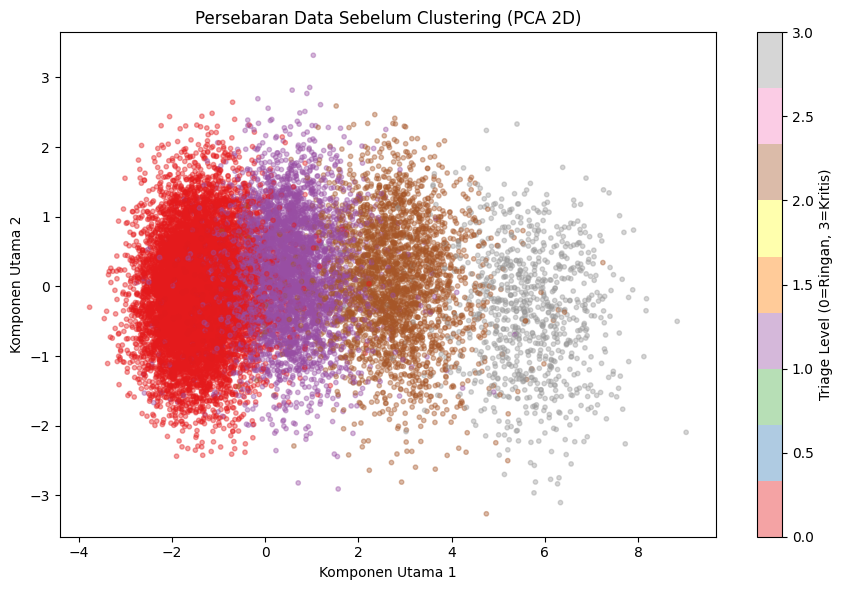

Variansi yang dijelaskan PCA: 63.18%

=== INSIGHT EDA ===
1. Distribusi age, heart_rate, systolic_blood_pressure, dan body_temperature
   mendekati distribusi normal, menandakan data tervariasi secara wajar.
2. pain_level, chronic_disease_count, dan previous_er_visits berdistribusi
   skewed ke kanan — mayoritas pasien memiliki nilai rendah pada ketiga fitur ini.
3. Berdasarkan boxplot, hampir semua fitur klinis meningkat seiring
   naiknya triage level — menunjukkan fitur-fitur ini relevan untuk segmentasi.
4. oxygen_saturation berkorelasi negatif kuat (-0.71) dengan triage_level,
   artinya pasien kritis cenderung memiliki saturasi oksigen lebih rendah.
5. pain_level memiliki korelasi tertinggi (0.90) dengan triage_level,
   menjadikannya fitur paling dominan dalam membedakan tingkat keparahan pasien.
6. Visualisasi PCA 2D menunjukkan data tersebar mengikuti gradasi triage level
   dari kiri ke kanan, membuktikan adanya struktur pengelompokan alami dalam data.


In [3]:
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(X_raw.columns):
    sns.histplot(data=X_raw, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Pasien')
plt.suptitle('Distribusi Seluruh Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(X_raw.columns):
    sns.boxplot(data=df, x='triage_level', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} per Triage Level')
    axes[i].set_xlabel('Triage Level (0=Ringan, 3=Kritis)')
plt.suptitle('Sebaran Fitur per Triage Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

numerik_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 7))
sns.heatmap(numerik_df.corr().round(2), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_raw)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_viz)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='Set1', alpha=0.4, s=10)
plt.colorbar(scatter, label='Triage Level (0=Ringan, 3=Kritis)')
plt.title('Persebaran Data Sebelum Clustering (PCA 2D)')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.tight_layout()
plt.show()

print(f"Variansi yang dijelaskan PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print("\n=== INSIGHT EDA ===")
print("1. Distribusi age, heart_rate, systolic_blood_pressure, dan body_temperature")
print("   mendekati distribusi normal, menandakan data tervariasi secara wajar.")
print("2. pain_level, chronic_disease_count, dan previous_er_visits berdistribusi")
print("   skewed ke kanan — mayoritas pasien memiliki nilai rendah pada ketiga fitur ini.")
print("3. Berdasarkan boxplot, hampir semua fitur klinis meningkat seiring")
print("   naiknya triage level — menunjukkan fitur-fitur ini relevan untuk segmentasi.")
print("4. oxygen_saturation berkorelasi negatif kuat (-0.71) dengan triage_level,")
print("   artinya pasien kritis cenderung memiliki saturasi oksigen lebih rendah.")
print("5. pain_level memiliki korelasi tertinggi (0.90) dengan triage_level,")
print("   menjadikannya fitur paling dominan dalam membedakan tingkat keparahan pasien.")
print("6. Visualisasi PCA 2D menunjukkan data tersebar mengikuti gradasi triage level")
print("   dari kiri ke kanan, membuktikan adanya struktur pengelompokan alami dalam data.")

Menghitung metrik untuk setiap nilai K...
K      Inertia         Silhouette      DBI       
----------------------------------------------
2      87338.86        0.4014          1.0981    
3      75369.01        0.2237          1.5939    
4      69967.17        0.1823          1.8078    
5      66033.91        0.1201          2.0283    
6      63317.01        0.1099          1.9793    
7      60803.39        0.1089          1.9929    
8      58706.43        0.1090          2.0979    
9      57048.12        0.1101          2.0120    
10     55401.15        0.1047          2.0221    


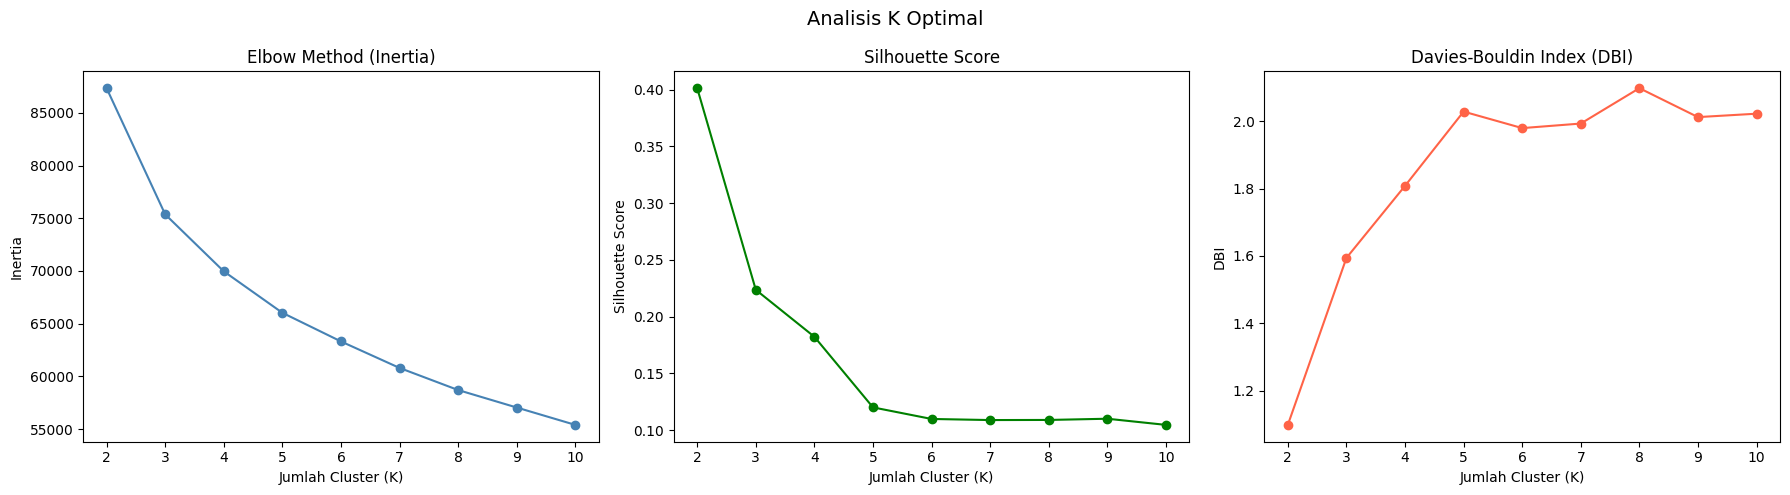


K terbaik berdasarkan Silhouette Score tertinggi : K = 2
K terbaik berdasarkan DBI terendah              : K = 2

>> Catatan: Metrik analitik menunjukkan K=2 secara matematis.
>> Namun berdasarkan domain knowledge, triage medis memiliki 4 level
>> (Ringan, Sedang, Berat, Kritis) yang tercermin dalam label triage_level.
>> Oleh karena itu, K=4 dipilih sebagai jumlah cluster final
>> dengan mempertimbangkan konteks masalah dan tujuan segmentasi pasien.

>> K FINAL yang digunakan untuk semua algoritma : K = 4


In [4]:
# ============================================================
# CELL 4: MENCARI K OPTIMAL (ELBOW + SILHOUETTE + DBI)
# ============================================================

# Standarisasi sementara hanya untuk analisis K optimal
scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X_raw)

k_range = range(2, 11)

inertia_list    = []
silhouette_list = []
dbi_list        = []

print('Menghitung metrik untuk setiap nilai K...')
print(f'{"K":<6} {"Inertia":<15} {"Silhouette":<15} {"DBI":<10}')
print('-' * 46)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_temp)

    inertia = km.inertia_
    sil     = silhouette_score(X_scaled_temp, labels)
    dbi     = davies_bouldin_score(X_scaled_temp, labels)

    inertia_list.append(inertia)
    silhouette_list.append(sil)
    dbi_list.append(dbi)

    print(f'{k:<6} {inertia:<15.2f} {sil:<15.4f} {dbi:<10.4f}')

# Visualisasi 3 Metrik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertia_list, marker='o', color='steelblue')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_list, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

axes[2].plot(k_range, dbi_list, marker='o', color='tomato')
axes[2].set_title('Davies-Bouldin Index (DBI)')
axes[2].set_xlabel('Jumlah Cluster (K)')
axes[2].set_ylabel('DBI')
axes[2].set_xticks(list(k_range))

plt.suptitle('Analisis K Optimal', fontsize=14)
plt.tight_layout()
plt.show()

# Kesimpulan pemilihan K
best_k_sil = list(k_range)[silhouette_list.index(max(silhouette_list))]
best_k_dbi = list(k_range)[dbi_list.index(min(dbi_list))]

print(f'\nK terbaik berdasarkan Silhouette Score tertinggi : K = {best_k_sil}')
print(f'K terbaik berdasarkan DBI terendah              : K = {best_k_dbi}')
print()
print('>> Catatan: Metrik analitik menunjukkan K=2 secara matematis.')
print('>> Namun berdasarkan domain knowledge, triage medis memiliki 4 level')
print('>> (Ringan, Sedang, Berat, Kritis) yang tercermin dalam label triage_level.')
print('>> Oleh karena itu, K=4 dipilih sebagai jumlah cluster final')
print('>> dengan mempertimbangkan konteks masalah dan tujuan segmentasi pasien.')

# Tetapkan K final
K_OPTIMAL = 4
print(f'\n>> K FINAL yang digunakan untuk semua algoritma : K = {K_OPTIMAL}')

In [5]:
# ============================================================
# CELL 5: FUNGSI BANTU & KONFIGURASI EKSPERIMEN
# ============================================================

# Fungsi Purity Score (konversi cluster ke akurasi)
def calculate_purity(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    labels = np.zeros_like(y_pred)
    for i in np.unique(y_pred):
        mask = (y_pred == i)
        labels[mask] = mode(y_true[mask], keepdims=True)[0][0]
    return accuracy_score(y_true, labels)

# Skenario data splitting
splits = [
    (0.3, '70:30'),
    (0.2, '80:20'),
    (0.1, '90:10')
]

print('Fungsi Purity Score siap digunakan.')
print(f'K yang digunakan: {K_OPTIMAL}')
print(f'Skenario splitting: {[s[1] for s in splits]}')

Fungsi Purity Score siap digunakan.
K yang digunakan: 4
Skenario splitting: ['70:30', '80:20', '90:10']


In [6]:
# ============================================================
# CELL 6: ALGORITMA 1 - K-MEANS++
# ============================================================

print('=== ALGORITMA 1: K-MEANS++ ===')
print(f'K yang digunakan: {K_OPTIMAL}')
print()

results_kmeans = []

for test_size, label in splits:
    # 1. Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_true, test_size=test_size, random_state=42
    )

    # 2. Scaling (fit HANYA di training, transform keduanya)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # 3. Model Building & Hyperparameter Tuning
    # Tuning: mencoba variasi n_init untuk hasil centroid terbaik
    best_purity = 0
    best_n_init = 0

    for n_init in [10, 20, 30]:
        km = KMeans(n_clusters=K_OPTIMAL, init='k-means++',
                    n_init=n_init, random_state=42)
        km.fit(X_train_scaled)
        preds = km.predict(X_test_scaled)
        purity = calculate_purity(y_test, preds)
        if purity > best_purity:
            best_purity = purity
            best_n_init = n_init
            best_model_km = km
            best_preds_km = preds

    # 4. Evaluasi Internal pada test set
    sil = silhouette_score(X_test_scaled, best_preds_km)
    dbi = davies_bouldin_score(X_test_scaled, best_preds_km)

    results_kmeans.append({
        'Split': label,
        'n_init': best_n_init,
        'Purity (%)': round(best_purity * 100, 2),
        'Silhouette': round(sil, 4),
        'DBI': round(dbi, 4)
    })

    print(f'-> Split {label}')
    print(f'   Hyperparameter terbaik (n_init) : {best_n_init}')
    print(f'   Purity Score (Akurasi)          : {best_purity*100:.2f}%')
    print(f'   Silhouette Score                : {sil:.4f}')
    print(f'   Davies-Bouldin Index            : {dbi:.4f}')
    print()

df_results_kmeans = pd.DataFrame(results_kmeans)
print('Ringkasan Hasil K-Means++:')
display(df_results_kmeans)

=== ALGORITMA 1: K-MEANS++ ===
K yang digunakan: 4

-> Split 70:30
   Hyperparameter terbaik (n_init) : 10
   Purity Score (Akurasi)          : 87.67%
   Silhouette Score                : 0.1829
   Davies-Bouldin Index            : 1.8128

-> Split 80:20
   Hyperparameter terbaik (n_init) : 10
   Purity Score (Akurasi)          : 88.11%
   Silhouette Score                : 0.1840
   Davies-Bouldin Index            : 1.8010

-> Split 90:10
   Hyperparameter terbaik (n_init) : 10
   Purity Score (Akurasi)          : 88.39%
   Silhouette Score                : 0.1876
   Davies-Bouldin Index            : 1.7710

Ringkasan Hasil K-Means++:


,Split,n_init,Purity (%),Silhouette,DBI
0,70:30,10,87.67,0.1829,1.8128
1,80:20,10,88.11,0.1840,1.8010
2,90:10,10,88.39,0.1876,1.7710


In [7]:
# ============================================================
# CELL 7: ALGORITMA 2 - GAUSSIAN MIXTURE MODEL (GMM)
# ============================================================

print('=== ALGORITMA 2: GAUSSIAN MIXTURE MODEL (GMM) ===')
print(f'K (n_components) yang digunakan: {K_OPTIMAL}')
print()

results_gmm = []

for test_size, label in splits:
    # 1. Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_true, test_size=test_size, random_state=42
    )

    # 2. Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # 3. Hyperparameter Tuning: covariance_type + n_init + max_iter
    best_purity  = 0
    best_params  = {}

    for cov_type in ['full', 'tied', 'diag', 'spherical']:
        for n_init in [1, 3, 5]:
            for max_iter in [100, 200, 300]:
                gmm = GaussianMixture(
                    n_components=K_OPTIMAL,
                    covariance_type=cov_type,
                    n_init=n_init,
                    max_iter=max_iter,
                    random_state=42
                )
                gmm.fit(X_train_scaled)
                preds  = gmm.predict(X_test_scaled)
                purity = calculate_purity(y_test, preds)

                if purity > best_purity:
                    best_purity  = purity
                    best_params  = {
                        'covariance_type': cov_type,
                        'n_init': n_init,
                        'max_iter': max_iter
                    }
                    best_preds_gmm = preds

    # 4. Evaluasi Internal
    sil = silhouette_score(X_test_scaled, best_preds_gmm)
    dbi = davies_bouldin_score(X_test_scaled, best_preds_gmm)

    results_gmm.append({
        'Split': label,
        'covariance_type': best_params['covariance_type'],
        'n_init': best_params['n_init'],
        'max_iter': best_params['max_iter'],
        'Purity (%)': round(best_purity * 100, 2),
        'Silhouette': round(sil, 4),
        'DBI': round(dbi, 4)
    })

    print(f'-> Split {label}')
    print(f'   Hyperparameter terbaik:')
    print(f'   - covariance_type : {best_params["covariance_type"]}')
    print(f'   - n_init          : {best_params["n_init"]}')
    print(f'   - max_iter        : {best_params["max_iter"]}')
    print(f'   Purity Score (Akurasi) : {best_purity*100:.2f}%')
    print(f'   Silhouette Score       : {sil:.4f}')
    print(f'   Davies-Bouldin Index   : {dbi:.4f}')
    print()

df_results_gmm = pd.DataFrame(results_gmm)
print('Ringkasan Hasil GMM:')
display(df_results_gmm)

=== ALGORITMA 2: GAUSSIAN MIXTURE MODEL (GMM) ===
K (n_components) yang digunakan: 4

-> Split 70:30
   Hyperparameter terbaik:
   - covariance_type : tied
   - n_init          : 1
   - max_iter        : 100
   Purity Score (Akurasi) : 93.33%
   Silhouette Score       : 0.1985
   Davies-Bouldin Index   : 1.7704

-> Split 80:20
   Hyperparameter terbaik:
   - covariance_type : tied
   - n_init          : 5
   - max_iter        : 100
   Purity Score (Akurasi) : 93.67%
   Silhouette Score       : 0.1973
   Davies-Bouldin Index   : 1.7577

-> Split 90:10
   Hyperparameter terbaik:
   - covariance_type : tied
   - n_init          : 3
   - max_iter        : 100
   Purity Score (Akurasi) : 94.00%
   Silhouette Score       : 0.1991
   Davies-Bouldin Index   : 1.7324

Ringkasan Hasil GMM:


,Split,covariance_type,n_init,max_iter,Purity (%),Silhouette,DBI
0,70:30,tied,1,100,93.33,0.1985,1.7704
1,80:20,tied,5,100,93.67,0.1973,1.7577
2,90:10,tied,3,100,94.00,0.1991,1.7324


In [8]:
# ============================================================
# CELL 8: ALGORITMA 3 - AGGLOMERATIVE CLUSTERING
# ============================================================

print('=== ALGORITMA 3: AGGLOMERATIVE CLUSTERING ===')
print(f'K (n_clusters) yang digunakan: {K_OPTIMAL}')
print()

results_agg = []

for test_size, label in splits:
    # 1. Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_true, test_size=test_size, random_state=42
    )

    # 2. Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # 3. Hyperparameter Tuning: linkage
    best_purity  = 0
    best_linkage = ''

    for linkage in ['ward', 'complete', 'average']:
        agg = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage=linkage)
        # Agglomerative tidak punya predict, jadi fit pada test langsung
        preds_train = agg.fit_predict(X_train_scaled)
        preds_test  = agg.fit_predict(X_test_scaled)
        purity = calculate_purity(y_test, preds_test)
        if purity > best_purity:
            best_purity  = purity
            best_linkage = linkage
            best_preds_agg = preds_test

    # 4. Evaluasi Internal
    sil = silhouette_score(X_test_scaled, best_preds_agg)
    dbi = davies_bouldin_score(X_test_scaled, best_preds_agg)

    results_agg.append({
        'Split': label,
        'linkage': best_linkage,
        'Purity (%)': round(best_purity * 100, 2),
        'Silhouette': round(sil, 4),
        'DBI': round(dbi, 4)
    })

    print(f'-> Split {label}')
    print(f'   Hyperparameter terbaik (linkage) : {best_linkage}')
    print(f'   Purity Score (Akurasi)           : {best_purity*100:.2f}%')
    print(f'   Silhouette Score                 : {sil:.4f}')
    print(f'   Davies-Bouldin Index             : {dbi:.4f}')
    print()

df_results_agg = pd.DataFrame(results_agg)
print('Ringkasan Hasil Agglomerative Clustering:')
display(df_results_agg)

=== ALGORITMA 3: AGGLOMERATIVE CLUSTERING ===
K (n_clusters) yang digunakan: 4

-> Split 70:30
   Hyperparameter terbaik (linkage) : ward
   Purity Score (Akurasi)           : 88.89%
   Silhouette Score                 : 0.1797
   Davies-Bouldin Index             : 1.8078

-> Split 80:20
   Hyperparameter terbaik (linkage) : ward
   Purity Score (Akurasi)           : 84.94%
   Silhouette Score                 : 0.1612
   Davies-Bouldin Index             : 1.8950

-> Split 90:10
   Hyperparameter terbaik (linkage) : ward
   Purity Score (Akurasi)           : 85.67%
   Silhouette Score                 : 0.1681
   Davies-Bouldin Index             : 1.8421

Ringkasan Hasil Agglomerative Clustering:


,Split,linkage,Purity (%),Silhouette,DBI
0,70:30,ward,88.89,0.1797,1.8078
1,80:20,ward,84.94,0.1612,1.8950
2,90:10,ward,85.67,0.1681,1.8421


=== PERBANDINGAN SEMUA ALGORITMA ===

Tabel Perbandingan Lengkap:


,Algoritma,Split,Purity (%),Silhouette,DBI
0,K-Means++,70:30,87.67,0.1829,1.8128
1,K-Means++,80:20,88.11,0.1840,1.8010
2,K-Means++,90:10,88.39,0.1876,1.7710
3,GMM,70:30,93.33,0.1985,1.7704
4,GMM,80:20,93.67,0.1973,1.7577
5,GMM,90:10,94.00,0.1991,1.7324
6,Agglomerative,70:30,88.89,0.1797,1.8078
7,Agglomerative,80:20,84.94,0.1612,1.8950
8,Agglomerative,90:10,85.67,0.1681,1.8421


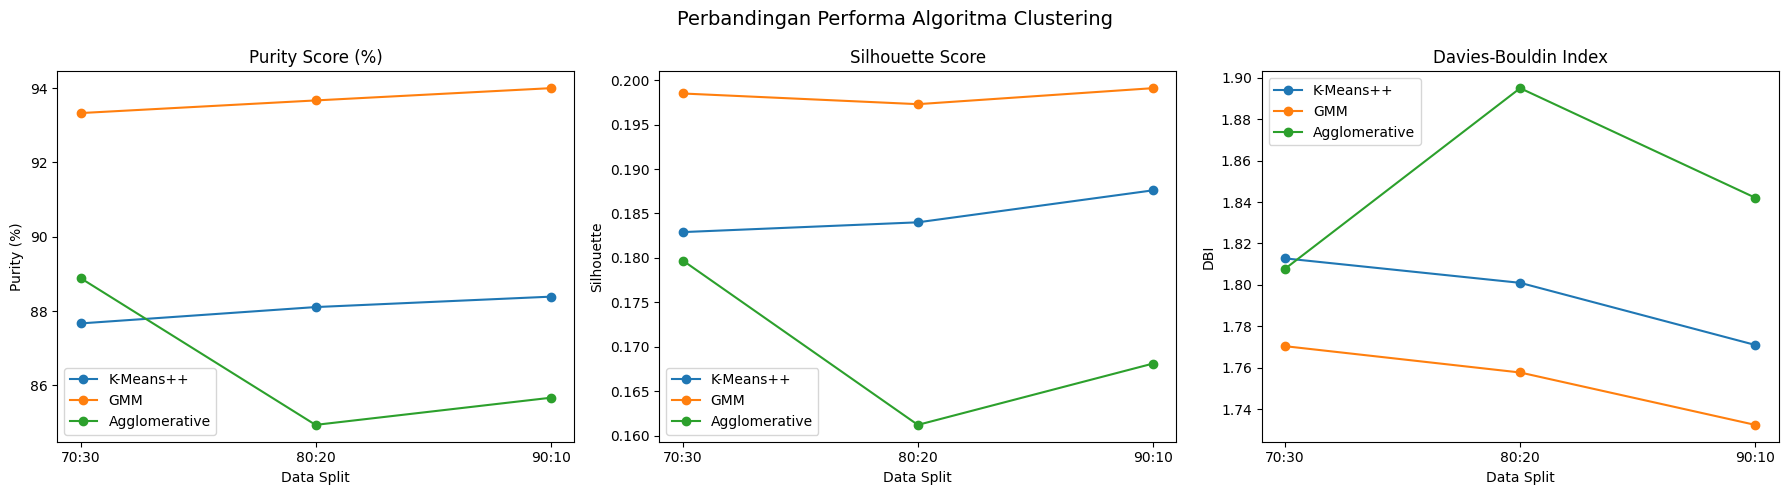

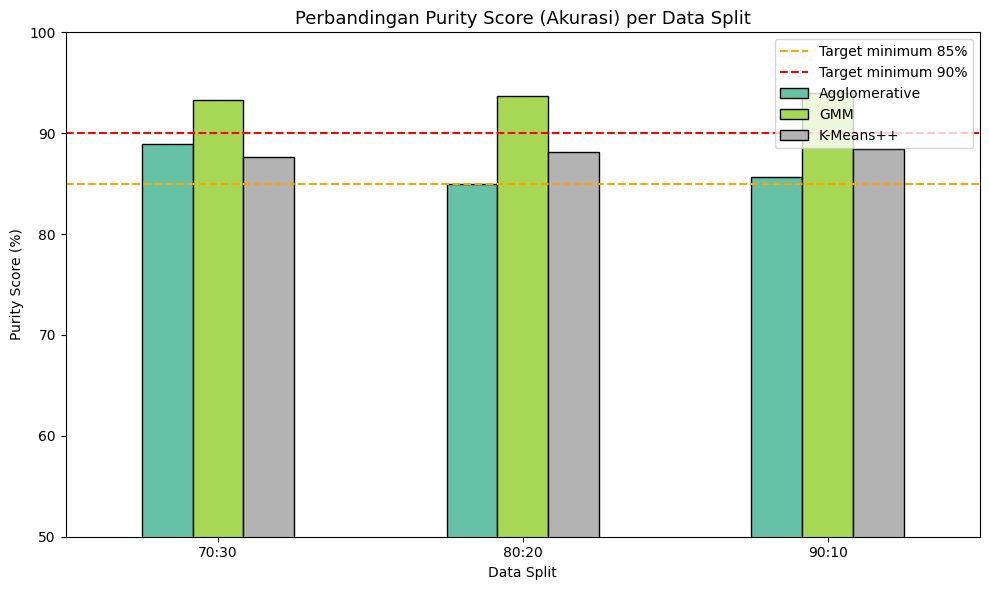


=== PURITY SCORE TERBAIK PER ALGORITMA ===



,Algoritma,Purity Terbaik (%),Pada Split
0,K-Means++,88.39,90:10
1,GMM,94.00,90:10
2,Agglomerative,88.89,70:30



=== VISUALISASI HASIL CLUSTERING (PCA 2D) ===


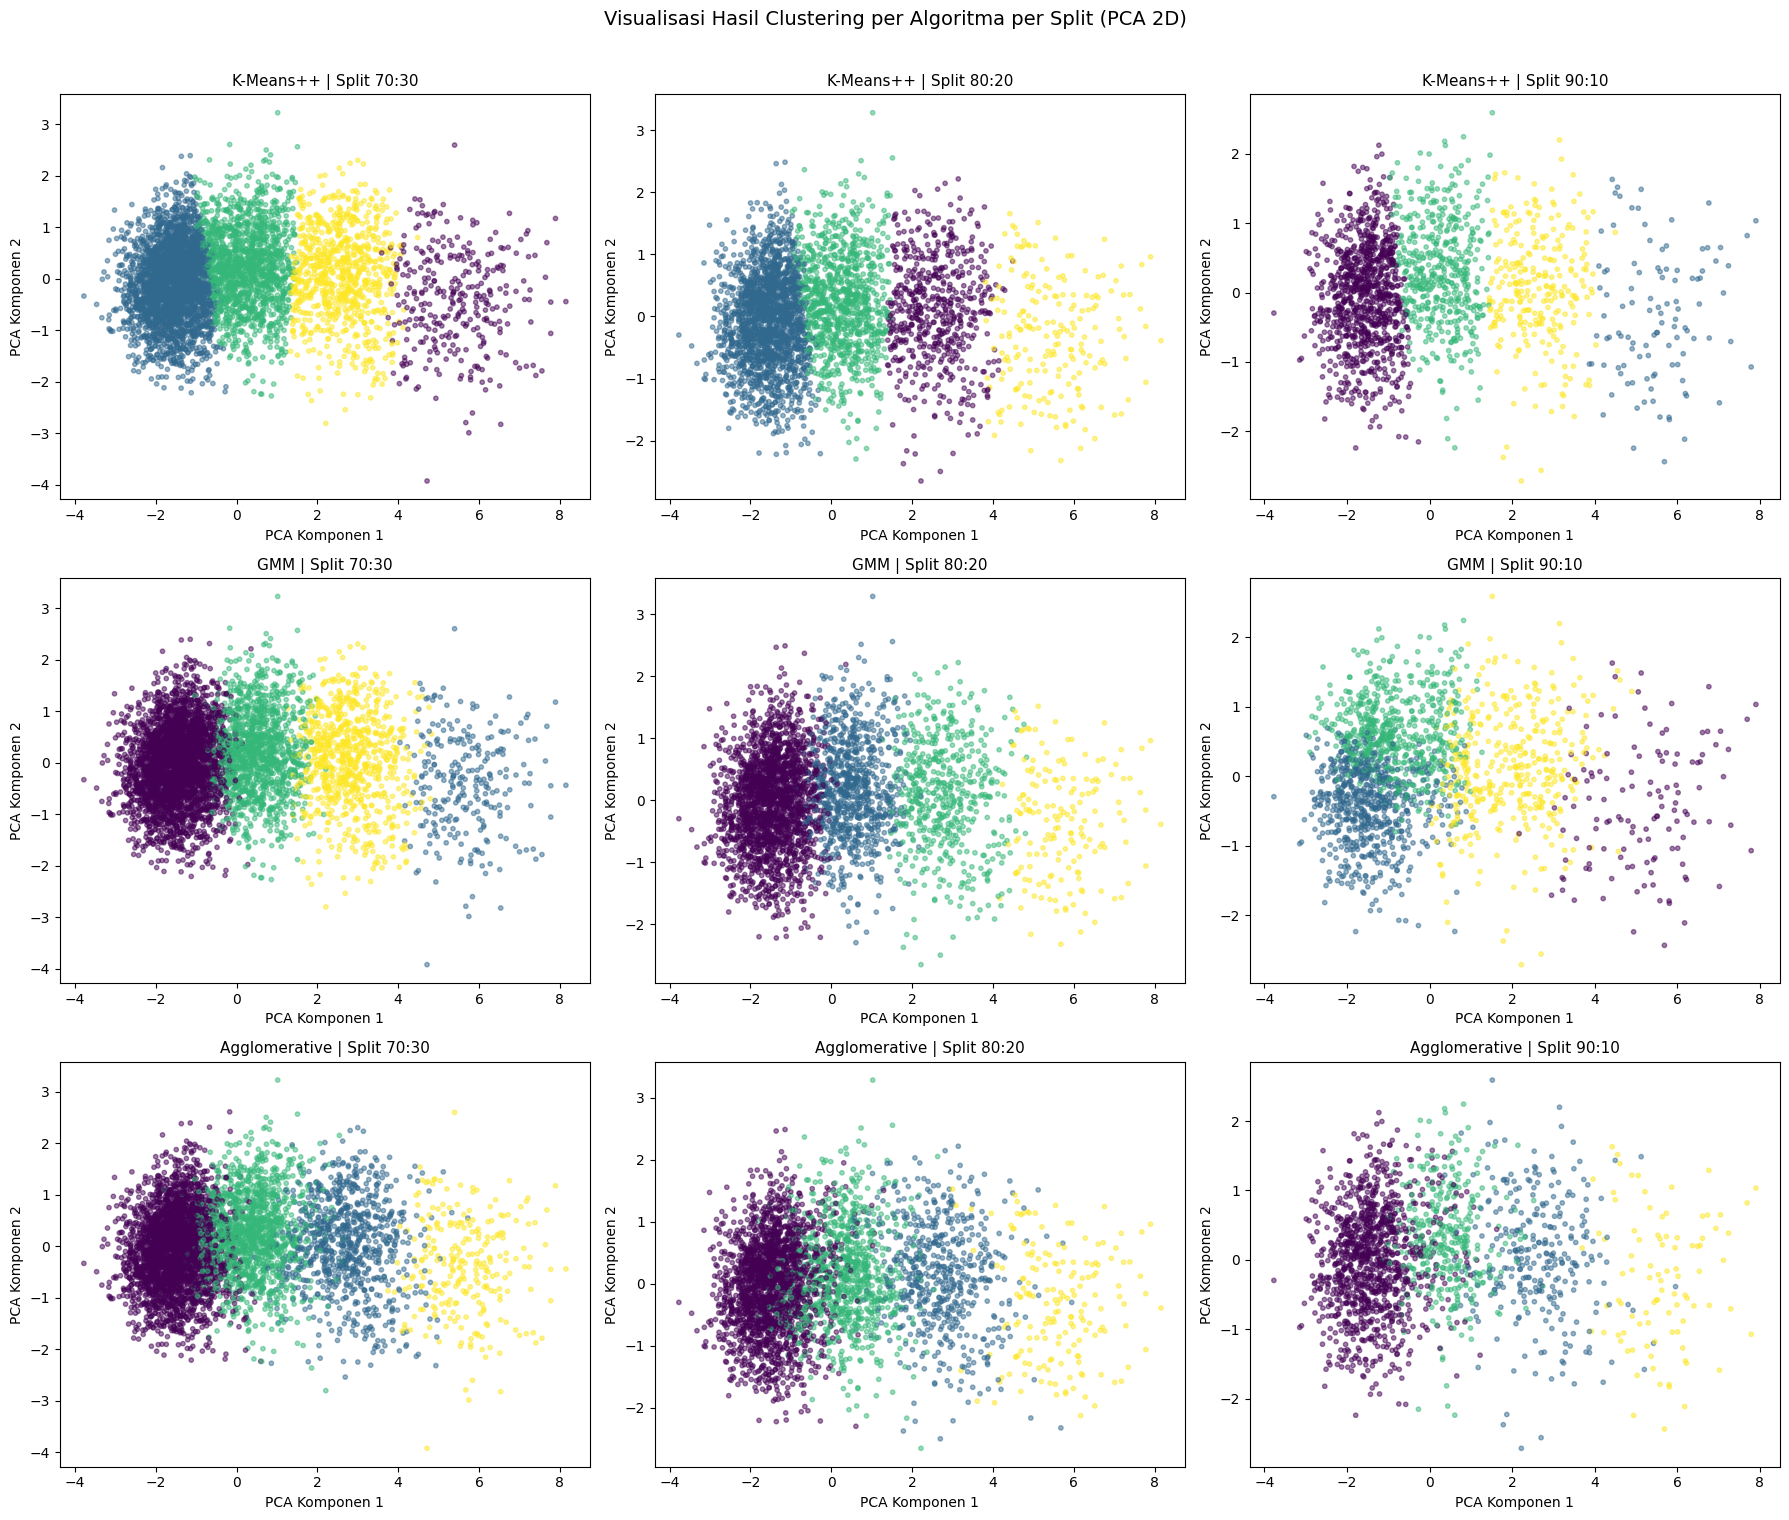


=== KESIMPULAN ===

K-Means++:
  Rata-rata Purity : 88.06%
  Purity Terbaik   : 88.39% (split 90:10)
  Status : ✓ Memenuhi target >= 85%

GMM:
  Rata-rata Purity : 93.67%
  Purity Terbaik   : 94.00% (split 90:10)
  Status : ✓ Memenuhi target >= 90%

Agglomerative:
  Rata-rata Purity : 86.50%
  Purity Terbaik   : 88.89% (split 70:30)
  Status : ✓ Memenuhi target >= 85%

Catatan: Evaluasi status menggunakan purity score tertinggi
yang dicapai setelah proses hyperparameter tuning pada setiap algoritma.


In [9]:
# ============================================================
# CELL 9: MODEL COMPARISON
# ============================================================

print('=== PERBANDINGAN SEMUA ALGORITMA ===')
print()

# Gabungkan hasil semua algoritma
df_kmeans_comp = df_results_kmeans[['Split', 'Purity (%)', 'Silhouette', 'DBI']].copy()
df_kmeans_comp.insert(0, 'Algoritma', 'K-Means++')

df_gmm_comp = df_results_gmm[['Split', 'Purity (%)', 'Silhouette', 'DBI']].copy()
df_gmm_comp.insert(0, 'Algoritma', 'GMM')

df_agg_comp = df_results_agg[['Split', 'Purity (%)', 'Silhouette', 'DBI']].copy()
df_agg_comp.insert(0, 'Algoritma', 'Agglomerative')

df_comparison = pd.concat([df_kmeans_comp, df_gmm_comp, df_agg_comp], ignore_index=True)

print('Tabel Perbandingan Lengkap:')
display(df_comparison)

# ---- Grafik 1: Line chart perbandingan Purity per Split ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Purity (%)', 'Silhouette', 'DBI']
titles  = ['Purity Score (%)', 'Silhouette Score', 'Davies-Bouldin Index']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    for algo in ['K-Means++', 'GMM', 'Agglomerative']:
        subset = df_comparison[df_comparison['Algoritma'] == algo]
        axes[i].plot(subset['Split'], subset[metric], marker='o', label=algo)
    axes[i].set_title(title)
    axes[i].set_xlabel('Data Split')
    axes[i].set_ylabel(metric)
    axes[i].legend()

plt.suptitle('Perbandingan Performa Algoritma Clustering', fontsize=14)
plt.tight_layout()
plt.show()

# ---- Grafik 2: Bar chart Purity Score ----
pivot_purity = df_comparison.pivot(index='Split', columns='Algoritma', values='Purity (%)')

pivot_purity.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Perbandingan Purity Score (Akurasi) per Data Split', fontsize=13)
plt.xlabel('Data Split')
plt.ylabel('Purity Score (%)')
plt.xticks(rotation=0)
plt.ylim(50, 100)
plt.axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Target minimum 85%')
plt.axhline(y=90, color='red',    linestyle='--', linewidth=1.5, label='Target minimum 90%')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Tabel Purity Tertinggi per Algoritma ----
print()
print('=== PURITY SCORE TERBAIK PER ALGORITMA ===')
print()

summary = []
for algo in ['K-Means++', 'GMM', 'Agglomerative']:
    subset     = df_comparison[df_comparison['Algoritma'] == algo]
    max_purity = subset['Purity (%)'].max()
    best_split = subset.loc[subset['Purity (%)'].idxmax(), 'Split']
    summary.append({
        'Algoritma': algo,
        'Purity Terbaik (%)': max_purity,
        'Pada Split': best_split
    })

df_summary = pd.DataFrame(summary)
display(df_summary)

# ---- Grafik 3: Visualisasi Hasil Clustering per Algoritma per Split (PCA 2D) ----

print()
print('=== VISUALISASI HASIL CLUSTERING (PCA 2D) ===')

# PCA untuk reduksi dimensi (hanya untuk visualisasi)
pca_vis = PCA(n_components=2)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

algo_names = ['K-Means++', 'GMM', 'Agglomerative']

for col_idx, (test_size, label) in enumerate(splits):

    # Split dan scaling ulang untuk visualisasi
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_true, test_size=test_size, random_state=42
    )

    scaler_vis = StandardScaler()
    X_train_scaled = scaler_vis.fit_transform(X_train)
    X_test_scaled  = scaler_vis.transform(X_test)

    # PCA fit pada training, transform pada test
    pca_vis.fit(X_train_scaled)
    X_test_pca = pca_vis.transform(X_test_scaled)

    # --- K-Means++ ---
    km_vis = KMeans(n_clusters=K_OPTIMAL, init='k-means++',
                    n_init=10, random_state=42)
    km_vis.fit(X_train_scaled)
    labels_km = km_vis.predict(X_test_scaled)

    # --- GMM ---
    gmm_vis = GaussianMixture(n_components=K_OPTIMAL,
                               covariance_type='tied',
                               random_state=42)
    gmm_vis.fit(X_train_scaled)
    labels_gmm = gmm_vis.predict(X_test_scaled)

    # --- Agglomerative ---
    agg_vis = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
    labels_agg = agg_vis.fit_predict(X_test_scaled)

    all_labels = [labels_km, labels_gmm, labels_agg]

    for row_idx, (algo_name, cluster_labels) in enumerate(zip(algo_names, all_labels)):
        ax = axes[row_idx][col_idx]
        scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                             c=cluster_labels, cmap='viridis',
                             alpha=0.5, s=10)
        ax.set_title(f'{algo_name} | Split {label}', fontsize=11)
        ax.set_xlabel('PCA Komponen 1')
        ax.set_ylabel('PCA Komponen 2')

plt.suptitle('Visualisasi Hasil Clustering per Algoritma per Split (PCA 2D)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ---- Kesimpulan ----
print()
print('=== KESIMPULAN ===')
print()

for algo in ['K-Means++', 'GMM', 'Agglomerative']:
    subset     = df_comparison[df_comparison['Algoritma'] == algo]
    max_purity = subset['Purity (%)'].max()
    avg_purity = subset['Purity (%)'].mean()
    best_split = subset.loc[subset['Purity (%)'].idxmax(), 'Split']

    print(f'{algo}:')
    print(f'  Rata-rata Purity : {avg_purity:.2f}%')
    print(f'  Purity Terbaik   : {max_purity:.2f}% (split {best_split})')

    if max_purity >= 90:
        print(f'  Status : ✓ Memenuhi target >= 90%')
    elif max_purity >= 85:
        print(f'  Status : ✓ Memenuhi target >= 85%')
    else:
        print(f'  Status : ✗ Belum memenuhi target')
    print()

print('Catatan: Evaluasi status menggunakan purity score tertinggi')
print('yang dicapai setelah proses hyperparameter tuning pada setiap algoritma.')